# 04 — Sequential calibration ablation
Test the sequential extension separately from projected marginal calibration. Every specification uses identical initialization, data order, forecast random numbers, and a fixed epoch budget. This removes checkpoint-selection and unequal-training-duration confounds.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.ca_rnn import TrainingConfig
from innovcal.data import simulate_multivariate_series
from innovcal.experiments import run_sequential_ablation
OUT = ROOT / 'results' / 'sequential_ablation'; OUT.mkdir(parents=True, exist_ok=True)

In [2]:
values = simulate_multivariate_series(1400, regime='heteroskedastic', seed=404)
config = TrainingConfig(epochs=100, batch_size=64, seed=404)
ablation_result = run_sequential_ablation(
    values,
    sequential_weights=[500.0, 2000.0, 5000.0, 10000.0],
    calibration_weight=100.0,
    training_config=config,
)
ablation = ablation_result.metrics
display(ablation)
ablation.to_csv(OUT / 'ablation.csv', index=False)
for name, history in ablation_result.histories.items():
    safe_name = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    history.to_csv(OUT / f'{safe_name}_history.csv', index=False)

,model,lambda_cal,lambda_seq,epochs,nll,rmse,energy_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
0,RNN,0.0,0.0,100,5.639677,0.924084,1.220149,0.873214,2.948130,4.096505,0.000790,0.055909,0.052063,0.001262,0.058686,0.066713
1,CA-RNN,100.0,0.0,100,5.234211,0.922185,1.210066,0.906250,3.136257,3.923580,0.000770,0.051821,0.051103,0.001236,0.055131,0.060495
2,CA-RNN sequential (500),100.0,500.0,100,5.225812,0.923158,1.211478,0.909821,3.172520,3.928220,0.000831,0.052442,0.052898,0.001298,0.055094,0.062250
3,CA-RNN sequential (2000),100.0,2000.0,100,5.208659,0.925820,1.215288,0.918750,3.262505,3.940920,0.001046,0.051316,0.059685,0.001540,0.052567,0.065626
4,CA-RNN sequential (5000),100.0,5000.0,100,5.239591,0.929961,1.223532,0.933036,3.413881,3.997437,0.001411,0.049975,0.067070,0.001928,0.049476,0.073396
5,CA-RNN sequential (10000),100.0,10000.0,100,5.305351,0.934957,1.237177,0.947321,3.639616,4.114660,0.002042,0.049248,0.079480,0.002499,0.047773,0.082330


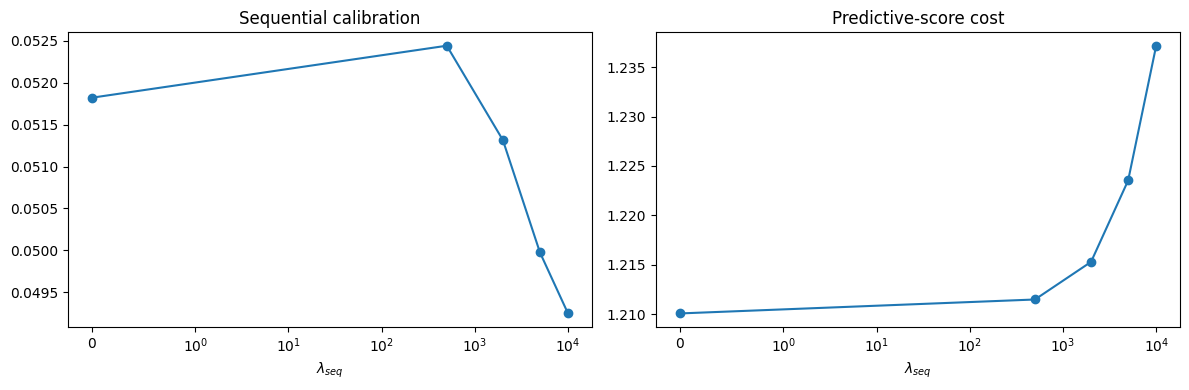

In [3]:
sequential = ablation.query("lambda_cal > 0").sort_values('lambda_seq')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sequential.lambda_seq, sequential.pit_mean_absolute_autocorrelation, marker='o')
axes[0].set_xscale('symlog', linthresh=1)
axes[0].set_title('Sequential calibration')
axes[0].set_xlabel(r'$\lambda_{seq}$')
axes[1].plot(sequential.lambda_seq, sequential.energy_score, marker='o')
axes[1].set_xscale('symlog', linthresh=1)
axes[1].set_title('Predictive-score cost')
axes[1].set_xlabel(r'$\lambda_{seq}$')
plt.tight_layout()

## Reading the ablation
Do not select a final weight from this test table. Look for a reproducible region in which PIT autocorrelation decreases without a disproportionate deterioration in NLL, Energy Score, interval score, or width. The later confirmatory design must select the weight using validation data and fresh seeds.